In [1]:
from pathlib import Path
import sys
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [2]:
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os
import tempfile
import numpy as np

from scipy.ndimage import label

from collections import Counter

from torch.utils.data import DataLoader

from datasets.wmh import WMH

In [3]:
WMH_DATASET_FOLDER = "/run/media/gianluca/Hard_drive/WMH"

In [4]:
from ipywidgets import interact, IntSlider, Dropdown
import ipywidgets as widgets
import scipy
from skimage.segmentation import find_boundaries


def explore_mri(img, mask, canonical=False, rotation=False, connected_components=False, show_boundaries=False):
    """
    :param img: filepath or nib or array
    :param mask: filepath or nib or array
    :param canonical: whether to use canonical RAS orientation
    :param rotation: wheter to rotate both the image and mask 90 degreees counter-clockwise
    :param connected_components: wheter to detect the connected components of the mask and treat them as different items
    :param show_boundaries: whetever to show only the boundaries of the mask instead of all its pixels
    """
    def get_data(src):
        if isinstance(src, str): # filepath
            nifti_data = nib.load(src)
            if canonical:
                nifti_data = nib.as_closest_canonical(nifti_data)
            data = nifti_data.get_fdata()
        elif isinstance(src, nib.Nifti1Image): # niftiimage
            data = src.get_fdata()
        else:
            data = np.asarray(src) # generic numpy array

        return data
    
    # Get data for image and mask
    img = get_data(img)
    mask = get_data(mask)
    
    # define dropdown menu selection for the plane of view
    plane_widget = Dropdown(
        options=["Sagittal", "Coronal", "Axial"],
        value="Axial",
        description="Plane:"
    )

    # define the slider for the images
    slice_slider = IntSlider(
        min=0,
        max=img.shape[2]-1,
        step=1,
        value=img.shape[2] // 2,
        description="Slice:",
        continuos_upldate=False
    )

    def update_slider(*args):
        plane = plane_widget.value

        if plane == "Axial":
            n_slices = img.shape[2]
        elif plane == "Coronal":
            n_slices = img.shape[1]
        else:  # Sagittal
            n_slices = img.shape[0]

        # determine maximum and minimum range by the number of slices available
        slice_slider.max = n_slices - 1
        slice_slider.value = n_slices // 2

    plane_widget.observe(update_slider, names="value")

    # find connected components in the segmentation mask
    if connected_components:
        labeled_mask, num_features = label(mask)
        colors = plt.cm.tab10(np.linspace(0,1,num_features))
        colors = np.vstack([[0,0,0,0],colors])
        cmap = ListedColormap(colors)

    def show_slice(plane, slice_idx):
        fig, ax = plt.subplots(figsize=(10,10))

        if plane == "Axial":
            img_slice = img[:, :, slice_idx]
            mask_slice = mask[:, :, slice_idx] if not connected_components else labeled_mask[:,:, slice_idx]

        elif plane == "Coronal":
            img_slice = img[:, slice_idx, :]
            mask_slice = mask[:, slice_idx, :] if not connected_components else labeled_mask[:, slice_idx, :]

        elif plane == "Sagittal":
            img_slice = img[slice_idx, :, :]
            mask_slice = mask[slice_idx, :, :] if not connected_components else labeled_mask[slice_idx,:, :]

        # apply rotation
        if rotation:
            img_slice = np.rot90(img_slice)
            mask_slice = np.rot90(mask_slice)

        # determine lesion boundaries
        if show_boundaries:
            boundary = find_boundaries(mask_slice)
            mask_slice = np.where(boundary, mask_slice, 0)
        
        ax.imshow(img_slice, cmap="grey")
        
        if not connected_components:
            ax.imshow(mask_slice, alpha=(mask_slice > 0).astype(float))
        else:
            ax.imshow(mask_slice, alpha=(mask_slice > 0).astype(float), cmap=cmap, vmin=0, vmax=num_features)
            
        ax.set_title(f"Slice {slice_idx}")
        plt.show()

    # define dropdown and slicer interface
    ui = widgets.HBox([plane_widget, slice_slider])
    out = widgets.interactive_output(
        show_slice,
        {
            "plane": plane_widget,
            "slice_idx": slice_slider
        }
    )

    display(ui, out)

# Preprocessing

1. Orientation to RAS
2. (Eventually) Rotation
3. Skull removal
4. Registration to a template

In [5]:
MNI_TEMPLATE_FILEPATH = "/run/media/gianluca/Hard_drive/MNI152_T1_1mm_brain.nii.gz"

df = WMH.get_metadata(WMH_DATASET_FOLDER)

t1w_filepath = df.iloc()[0]["T1W FILEPATH"]
flair_filepath = df.iloc()[0]["FLAIR FILEPATH"]
segmentation_filepath = df.iloc()[0]["SEGMENTATION FILEPATH"]

t1w_filepath = f"{WMH_DATASET_FOLDER}/{t1w_filepath}"
flair_filepath = f"{WMH_DATASET_FOLDER}/{flair_filepath}"
segmentation_filepath = f"{WMH_DATASET_FOLDER}/{segmentation_filepath}"

WMH.preprocess(
    t1w_filepath,
    flair_filepath,
    segmentation_filepath,
    MNI_TEMPLATE_FILEPATH,
    "/home/gianluca/Desktop/test"
)


########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False
There are 1 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 1 cases that I would like to predict

Predicting tmp0t6srp6z_bet.nii.gz:
perform_everything_on_device: False


100%|██████████| 8/8 [01:43<00:00, 12.96s/it]


sending off prediction to background worker for resampling and export
done with tmp0t6srp6z_bet.nii.gz
GPU prediction completed. Waiting for remaining segmentation exports to finish...


Segmentation export complete.
Perform registration


FileNotFoundError: No such file or no access: '/tmp/tmp666ca9lk/T1_MNI.nii.gz'

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(15,15))

input_t1w_nib = nib.load(t1w_filepath)
output_t1w_nib = nib.load("/home/gianluca/Desktop/test/t1w.nii.gz")

input_t1w_array = input_t1w_nib.get_fdata()
input_flair_array = nib.load(flair_filepath).get_fdata()
input_segmentation_array = nib.load(segmentation_filepath).get_fdata()
output_t1w_array = output_t1w_nib.get_fdata()
output_flair_array = nib.load("/home/gianluca/Desktop/test/flair.nii.gz").get_fdata()
output_segmentation_array = nib.load("/home/gianluca/Desktop/test/roi.nii.gz").get_fdata()

j = 52
i = 91

sx, sy, sz = input_t1w_nib.header.get_zooms()
axes[0,0].set_title(f"Input {input_t1w_array.shape} - ({sx:.2f},{sy:.2f},{sz:.2f})")

sx, sy, sz = output_t1w_nib.header.get_zooms()
axes[0,1].set_title(f"Output {output_t1w_array.shape} - ({sx:.2f},{sy:.2f},{sz:.2f})")

axes[0,0].imshow(input_t1w_array[:,:,j], cmap=plt.cm.grey)
axes[0,0].set_axis_off()

axes[0,1].imshow(output_t1w_array[:,:,i], cmap=plt.cm.grey)
axes[0,1].set_axis_off()

axes[1,0].imshow(input_flair_array[:,:,j], cmap=plt.cm.grey)
axes[1,0].set_axis_off()

axes[1,1].imshow(output_flair_array[:,:,i], cmap=plt.cm.grey)
axes[1,1].set_axis_off()

axes[2,0].imshow(input_flair_array[:,:,j], cmap=plt.cm.grey)
axes[2,0].imshow(input_segmentation_array[:,:,j], alpha=(input_segmentation_array[:,:,j] > 0).astype(float), cmap=plt.cm.grey)
axes[2,0].set_axis_off()

axes[2,1].imshow(output_flair_array[:,:,i], cmap=plt.cm.grey)
axes[2,1].imshow(output_segmentation_array[:,:,i], alpha=(output_segmentation_array[:,:,i] > 0).astype(float), cmap=plt.cm.grey)
axes[2,1].set_axis_off()

fig.tight_layout()
plt.show()

# tmp Preprocessing and saving in a folder

In [10]:
output_dir_filepath = "/home/gianluca/Desktop/test/"

MNI_TEMPLATE_FILEPATH = "/run/media/gianluca/Hard_drive/MNI152_T1_1mm_brain.nii.gz"

df = WMH.get_metadata(WMH_DATASET_FOLDER)

for _, row in list(df.iterrows())[:1]:
    patient_id = row["PATIENT"]
    
    t1w_filepath = row["T1W FILEPATH"]
    flair_filepath = row["FLAIR FILEPATH"]
    segmentation_filepath = row["SEGMENTATION FILEPATH"]
    
    t1w_filepath = f"{WMH_DATASET_FOLDER}/{t1w_filepath}"
    flair_filepath = f"{WMH_DATASET_FOLDER}/{flair_filepath}"
    segmentation_filepath = f"{WMH_DATASET_FOLDER}/{segmentation_filepath}"

    # create folder for patient data
    Path(f'{output_dir_filepath}/wmh_data/{patient_id}').mkdir(parents=True, exist_ok=True)
    
    WMH.preprocess(
        t1w_filepath,
        flair_filepath,
        segmentation_filepath,
        MNI_TEMPLATE_FILEPATH,
        f'{output_dir_filepath}/{patient_id}'
    )


########################
If you are using hd-bet, please cite the following papers:

Isensee F, Schell M, Tursunova I, Brugnara G, Bonekamp D, Neuberger U, Wick A, Schlemmer HP, Heiland S, Wick W, Bendszus M, Maier-Hein KH, Kickingereder P. Automated brain extraction of multi-sequence MRI using artificial neural networks. arXiv preprint arXiv:1901.11341, 2019.

Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
########################

perform_everything_on_device=True is only supported for cuda devices! Setting this to False
There are 1 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 1 cases that I would like to predict

Predicting tmpzfi9atyu_bet.nii.gz:
perform_everything_on_device: False


100%|██████████| 8/8 [01:51<00:00, 13.92s/it]


sending off prediction to background worker for resampling and export
done with tmpzfi9atyu_bet.nii.gz
GPU prediction completed. Waiting for remaining segmentation exports to finish...


Segmentation export complete.
Perform registration


# Explore the dataset

In [5]:
df = WMH.get_metadata(WMH_DATASET_FOLDER)

print("Number of patients: ", len(df))
print("Available T1W: ", df["T1W FILEPATH"].count())
print("Available FLAIR: ", df["FLAIR FILEPATH"].count())
print("Available SEGMENTATION: ", df["SEGMENTATION FILEPATH"].count())

df.head()

Number of patients:  170
Available T1W:  170
Available FLAIR:  170
Available SEGMENTATION:  170


,SET,CENTER,SCANNER,PATIENT,T1W FILEPATH,FLAIR FILEPATH,SEGMENTATION FILEPATH
0,training,Amsterdam,GE3T,100,wmh_data/training/Amsterdam/GE3T/100/pre/T1.nii,wmh_data/training/Amsterdam/GE3T/100/pre/FLAIR...,wmh_data/training/Amsterdam/GE3T/100/wmh.nii
1,training,Amsterdam,GE3T,101,wmh_data/training/Amsterdam/GE3T/101/pre/T1.nii,wmh_data/training/Amsterdam/GE3T/101/pre/FLAIR...,wmh_data/training/Amsterdam/GE3T/101/wmh.nii
2,training,Amsterdam,GE3T,102,wmh_data/training/Amsterdam/GE3T/102/pre/T1.nii,wmh_data/training/Amsterdam/GE3T/102/pre/FLAIR...,wmh_data/training/Amsterdam/GE3T/102/wmh.nii
3,training,Amsterdam,GE3T,103,wmh_data/training/Amsterdam/GE3T/103/pre/T1.nii,wmh_data/training/Amsterdam/GE3T/103/pre/FLAIR...,wmh_data/training/Amsterdam/GE3T/103/wmh.nii
4,training,Amsterdam,GE3T,104,wmh_data/training/Amsterdam/GE3T/104/pre/T1.nii,wmh_data/training/Amsterdam/GE3T/104/pre/FLAIR...,wmh_data/training/Amsterdam/GE3T/104/wmh.nii


In [8]:
t1w_filepath = df.iloc()[0]["T1W FILEPATH"]
flair_filepath = df.iloc()[0]["FLAIR FILEPATH"]
segmentation_filepath = df.iloc()[0]["SEGMENTATION FILEPATH"]

t1w_filepath = f"{WMH_DATASET_FOLDER}/{t1w_filepath}"
flair_filepath = f"{WMH_DATASET_FOLDER}/{flair_filepath}"
segmentation_filepath = f"{WMH_DATASET_FOLDER}/{segmentation_filepath}"

t1w_array = nib.load(t1w_filepath).get_fdata()
flair_array = nib.load(flair_filepath).get_fdata()
segmentation_array = nib.load(segmentation_filepath).get_fdata()

In [9]:
np.unique(segmentation_array)

array([0., 1.])

(np.float64(-0.5), np.float64(255.5), np.float64(131.5), np.float64(-0.5))

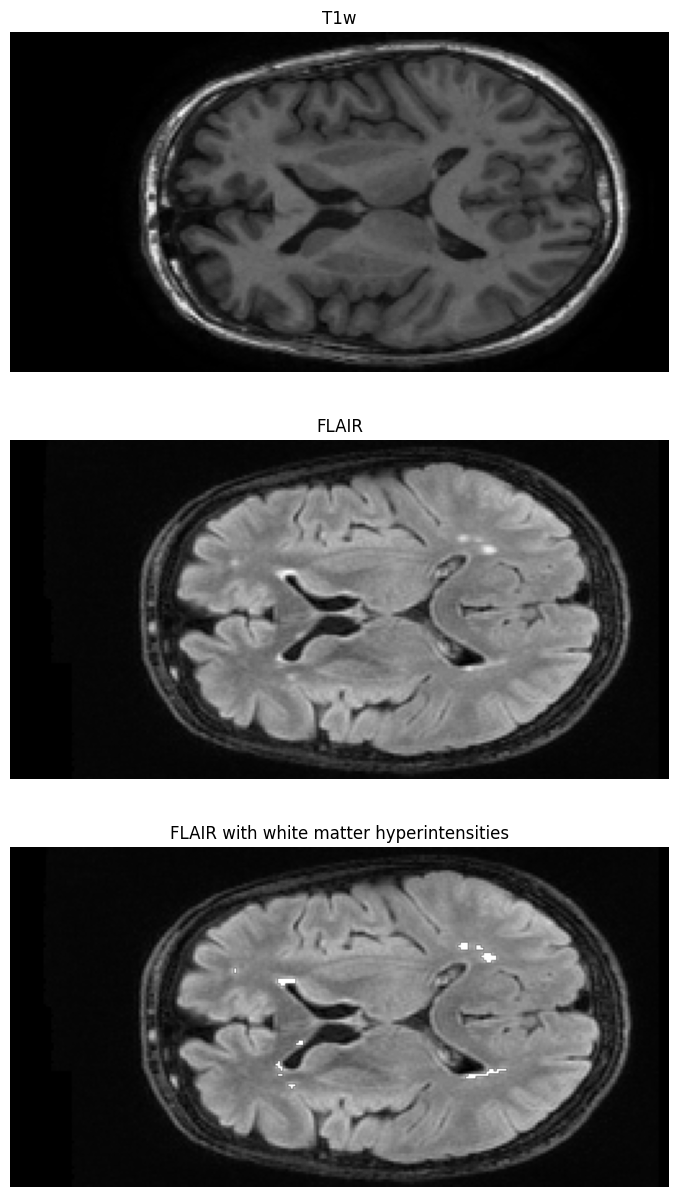

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(15,15))

axes[0].imshow(t1w_array[:,:,50], cmap=plt.cm.grey)
axes[0].set_title("T1w")
axes[0].axis("off")

axes[1].imshow(flair_array[:,:,50], cmap=plt.cm.grey)
axes[1].set_title("FLAIR")
axes[1].axis("off")

axes[2].imshow(flair_array[:,:,50], cmap=plt.cm.grey)
axes[2].imshow(segmentation_array[:,:,50], alpha=(segmentation_array[:,:,50] > 0).astype(float), cmap=plt.cm.grey)
axes[2].set_title("FLAIR with white matter hyperintensities")
axes[2].axis("off")

## Amsterdam center

In [13]:
t1w_filepath, flair_filepath, segmentation_filepath = df.iloc()[0]["T1W FILEPATH"], df.iloc()[0]["FLAIR FILEPATH"], df.iloc()[0]["SEGMENTATION FILEPATH"]

explore_mri(f"{WMH_DATASET_FOLDER}/{t1w_filepath}", f"{WMH_DATASET_FOLDER}/{segmentation_filepath}", rotation=True, connected_components=True, show_boundaries=True)

Output()

In [14]:
explore_mri(f"{WMH_DATASET_FOLDER}/{flair_filepath}", f"{WMH_DATASET_FOLDER}/{segmentation_filepath}", rotation=True, connected_components=True, show_boundaries=True)

Output()

## Singapore

In [15]:
t1w_filepath, flair_filepath, segmentation_filepath = df.iloc()[20]["T1W FILEPATH"], df.iloc()[20]["FLAIR FILEPATH"], df.iloc()[20]["SEGMENTATION FILEPATH"]

explore_mri(f"{WMH_DATASET_FOLDER}/{t1w_filepath}", f"{WMH_DATASET_FOLDER}/{segmentation_filepath}", rotation=True, connected_components=True, show_boundaries=True)

Output()

In [16]:
explore_mri(f"{WMH_DATASET_FOLDER}/{flair_filepath}", f"{WMH_DATASET_FOLDER}/{segmentation_filepath}", rotation=True, connected_components=True, show_boundaries=True)

Output()

## Exploring aquisition parameters

### Scanner

In [19]:
df["SCANNER"].value_counts()

SCANNER
GE3T                     150
GE1T5                     10
Philips_VU .PETMR_01.     10
Name: count, dtype: int64

### Matrix size

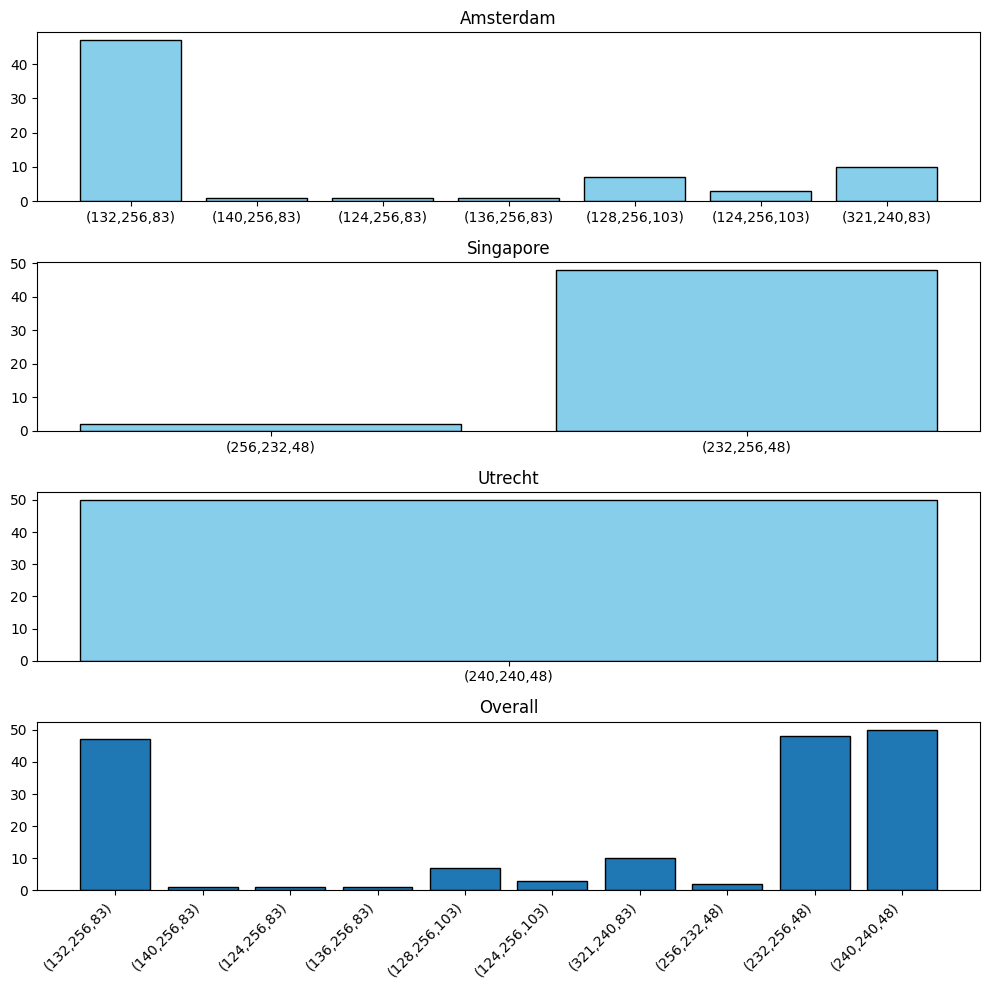

In [20]:
center_sizes = {
    "Amsterdam": [],
    "Singapore": [],
    "Utrecht": []
}

for center in center_sizes.keys():
    dl = DataLoader(WMH(WMH_DATASET_FOLDER, data_split=None, center=center), batch_size=1, shuffle=False)

    for t1, flair, segmentation in dl:
        t1, flair, segmentation = t1.squeeze(0), flair.squeeze(0), segmentation.squeeze(0) # squeezing batch dimension

        if t1.size() != flair.size() != segmentation.size():
            print("Sizes mismatch")

        center_sizes[center].append(t1.size())

fig, axs = plt.subplots(4, figsize=(10, 10))

center = "Amsterdam"
counts = Counter(center_sizes[center])
axs[0].bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
axs[0].set_title(center)

center = "Singapore"
counts = Counter(center_sizes[center])
axs[1].bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
axs[1].set_title(center)

center = "Utrecht"
counts = Counter(center_sizes[center])
axs[2].bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), color='skyblue', edgecolor='black')
axs[2].set_title(center)

counts = Counter(center_sizes["Amsterdam"] + center_sizes["Singapore"] + center_sizes["Utrecht"])
axs[3].bar([ f"({v[0]},{v[1]},{v[2]})" for v in counts.keys()], counts.values(), edgecolor='black')
axs[3].set_title("Overall")
plt.xticks(rotation=45, ha="right")

plt.tight_layout() 
plt.show()

### Voxel size

In [21]:
center_voxel_sizes = {
    center: {
        "t1": {
            "x": [], 
            "y": [], 
            "z": []
        },
        "flair": {
            "x": [], 
            "y": [], 
            "z": []
        }
    }
    for center in ["Amsterdam", "Singapore", "Utrecht"]
}

# AMSTERDAM
for scans_path in ["wmh_data/training/Amsterdam/GE3T", "wmh_data/test/Amsterdam/GE3T", "wmh_data/test/Amsterdam/GE1T5", "wmh_data/test/Amsterdam/Philips_VU .PETMR_01."]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        x, y, z = nib.load(t1_filepath).header.get_zooms()

        center_voxel_sizes["Amsterdam"]["t1"]["x"].append(x)
        center_voxel_sizes["Amsterdam"]["t1"]["y"].append(y)
        center_voxel_sizes["Amsterdam"]["t1"]["z"].append(z)

        # FLAIR
        x, y, z = nib.load(flair_filepath).header.get_zooms()

        center_voxel_sizes["Amsterdam"]["flair"]["x"].append(x)
        center_voxel_sizes["Amsterdam"]["flair"]["y"].append(y)
        center_voxel_sizes["Amsterdam"]["flair"]["z"].append(z)

# SINGAPORE
for scans_path in ["wmh_data/training/Singapore", "wmh_data/test/Singapore"]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        x, y, z = nib.load(t1_filepath).header.get_zooms()

        center_voxel_sizes["Singapore"]["t1"]["x"].append(x)
        center_voxel_sizes["Singapore"]["t1"]["y"].append(y)
        center_voxel_sizes["Singapore"]["t1"]["z"].append(z)

        # FLAIR
        x, y, z = nib.load(flair_filepath).header.get_zooms()

        center_voxel_sizes["Singapore"]["flair"]["x"].append(x)
        center_voxel_sizes["Singapore"]["flair"]["y"].append(y)
        center_voxel_sizes["Singapore"]["flair"]["z"].append(z)

# UTRECHT
for scans_path in ["wmh_data/training/Utrecht", "wmh_data/test/Utrecht"]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        x, y, z = nib.load(t1_filepath).header.get_zooms()

        center_voxel_sizes["Utrecht"]["t1"]["x"].append(x)
        center_voxel_sizes["Utrecht"]["t1"]["y"].append(y)
        center_voxel_sizes["Utrecht"]["t1"]["z"].append(z)

        # FLAIR
        x, y, z = nib.load(flair_filepath).header.get_zooms()

        center_voxel_sizes["Utrecht"]["flair"]["x"].append(x)
        center_voxel_sizes["Utrecht"]["flair"]["y"].append(y)
        center_voxel_sizes["Utrecht"]["flair"]["z"].append(z)

for center in ["Amsterdam", "Singapore", "Utrecht"]:
    print(f"-- {center} --")
    t1_x_mean, t1_x_std = np.mean(center_voxel_sizes[center]["t1"]["x"]), np.std(center_voxel_sizes[center]["t1"]["x"])
    t1_y_mean, t1_y_std = np.mean(center_voxel_sizes[center]["t1"]["y"]), np.std(center_voxel_sizes[center]["t1"]["y"])
    t1_z_mean, t1_z_std = np.mean(center_voxel_sizes[center]["t1"]["z"]), np.std(center_voxel_sizes[center]["t1"]["z"])
    
    flair_x_mean, flair_x_std = np.mean(center_voxel_sizes[center]["flair"]["x"]), np.std(center_voxel_sizes[center]["flair"]["x"])
    flair_y_mean, flair_y_std = np.mean(center_voxel_sizes[center]["flair"]["y"]), np.std(center_voxel_sizes[center]["flair"]["y"])
    flair_z_mean, flair_z_std = np.mean(center_voxel_sizes[center]["flair"]["z"]), np.std(center_voxel_sizes[center]["flair"]["z"])
    
    print(f"[T1] ({t1_x_mean:.2f}±{t1_x_std:.2f}, {t1_y_mean:.2f}±{t1_y_std:.2f}, {t1_z_mean:.2f}±{t1_z_std:.2f})")
    print(f"[FLAIR] ({flair_x_mean:.2f}±{flair_x_std:.2f}, {flair_y_mean:.2f}±{flair_y_std:.2f}, {flair_z_mean:.2f}±{flair_z_std:.2f})")

    print()

-- Amsterdam --
[T1] (1.12±0.23, 1.02±0.08, 3.00±0.00)
[FLAIR] (1.12±0.23, 1.02±0.08, 3.00±0.00)

-- Singapore --
[T1] (1.00±0.00, 1.00±0.00, 3.00±0.00)
[FLAIR] (1.00±0.00, 1.00±0.00, 3.00±0.00)

-- Utrecht --
[T1] (0.96±0.00, 0.96±0.00, 3.00±0.00)
[FLAIR] (0.96±0.00, 0.96±0.00, 3.00±0.00)



### Orientation

https://stackoverflow.com/questions/66231763/how-to-check-nifti-image-is-in-the-right-orientation-position-with-python

In [22]:
orientations = {
    "t1": [],
    "flair": []
}

# AMSTERDAM
for scans_path in ["wmh_data/training/Amsterdam/GE3T", "wmh_data/test/Amsterdam/GE3T", "wmh_data/test/Amsterdam/GE1T5", "wmh_data/test/Amsterdam/Philips_VU .PETMR_01."]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        t1_orientation = nib.aff2axcodes(nib.load(t1_filepath).affine)
        orientations["t1"].append(t1_orientation)

        # FLAIR
        flair_orientation = nib.aff2axcodes(nib.load(flair_filepath).affine)
        orientations["flair"].append(flair_orientation)

# SINGAPORE
for scans_path in ["wmh_data/training/Singapore", "wmh_data/test/Singapore"]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        t1_orientation = nib.aff2axcodes(nib.load(t1_filepath).affine)
        orientations["t1"].append(t1_orientation)

        # FLAIR
        flair_orientation = nib.aff2axcodes(nib.load(flair_filepath).affine)
        orientations["flair"].append(flair_orientation)

# UTRECHT
for scans_path in ["wmh_data/training/Utrecht", "wmh_data/test/Utrecht"]:
    t1_filepaths, flair_filepaths, segmentation_filepaths = WMH.get_scans_filepath(f"{WMH_DATASET_FOLDER}/{scans_path}")

    for t1_filepath, flair_filepath in zip(t1_filepaths, flair_filepaths):
        # T1
        t1_orientation = nib.aff2axcodes(nib.load(t1_filepath).affine)
        orientations["t1"].append(t1_orientation)

        # FLAIR
        flair_orientation = nib.aff2axcodes(nib.load(flair_filepath).affine)
        orientations["flair"].append(flair_orientation)

#######################
# Printing orientations
#######################
print(np.unique_counts(orientations["t1"]))
print(np.unique_counts(orientations["flair"]))

UniqueCountsResult(values=array(['L', 'P', 'S'], dtype='<U1'), counts=array([170, 170, 170]))
UniqueCountsResult(values=array(['L', 'P', 'S'], dtype='<U1'), counts=array([170, 170, 170]))


In [ ]:
# conversion to RAS
img_ras = nib.as_closest_canonical(img)
print(nib.aff2axcodes(img_ras.affine))

## Skull stripping

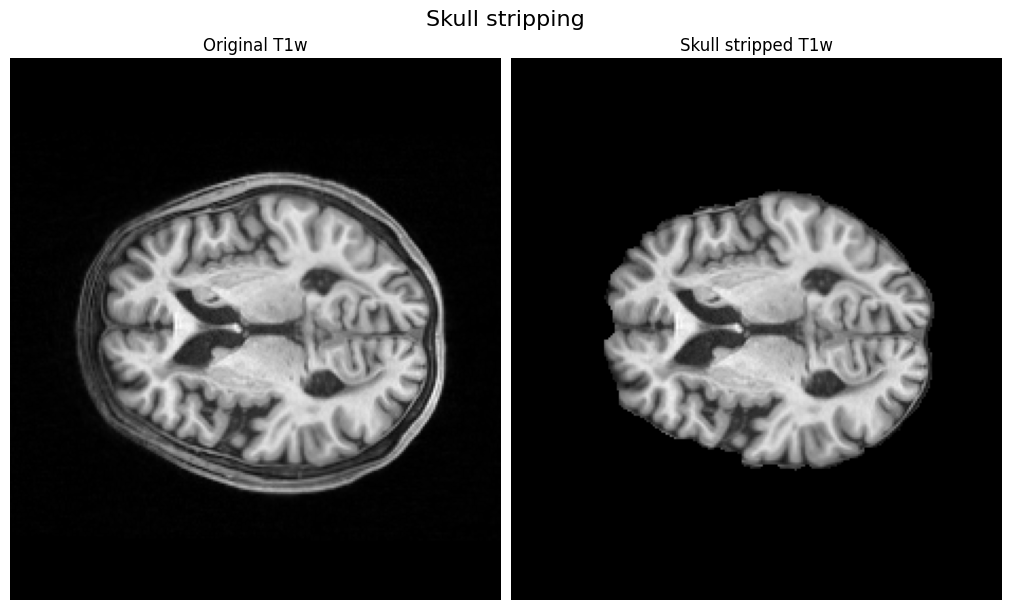

In [40]:
from fsl.wrappers import bet
from pathlib import Path
import tempfile

with tempfile.TemporaryDirectory() as tmpdir:
    t1w_brain_filepath = f"{tmpdir}/T1w_brain.nii.gz"
    bet(
        f"{WMH_DATASET_FOLDER}/{t1w_filepath}",
        t1w_brain_filepath
    )

    t1w_brain_data = nib.load(t1w_brain_filepath).get_fdata()
    t1w_original_data = nib.load(f"{WMH_DATASET_FOLDER}/{t1w_filepath}").get_fdata()

    fig, axes = plt.subplots(1, 2, figsize=(10,6), constrained_layout=True)
    fig.suptitle("Skull stripping", fontsize=16)

    axes[0].imshow(t1w_original_data[:,:,24], cmap=plt.cm.gray)   
    axes[0].axis("off")
    axes[0].set_title("Original T1w")

    axes[1].imshow(t1w_brain_data[:,:,24], cmap=plt.cm.gray)
    axes[1].axis("off")
    axes[1].set_title("Skull stripped T1w")
    

## Exploratory anaylsis for multicenter variability

In [41]:
df = WMH.get_metadata(WMH_DATASET_FOLDER)
df = df[["CENTER", "SCANNER", "T1W FILEPATH"]]
df.head()

,CENTER,SCANNER,T1W FILEPATH
0,Amsterdam,GE3T,wmh_data/training/Amsterdam/GE3T/100/pre/T1.nii
1,Amsterdam,GE3T,wmh_data/training/Amsterdam/GE3T/101/pre/T1.nii
2,Amsterdam,GE3T,wmh_data/training/Amsterdam/GE3T/102/pre/T1.nii
3,Amsterdam,GE3T,wmh_data/training/Amsterdam/GE3T/103/pre/T1.nii
4,Amsterdam,GE3T,wmh_data/training/Amsterdam/GE3T/104/pre/T1.nii


<Axes: >

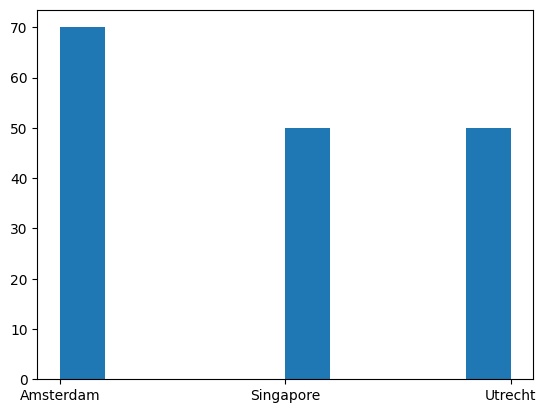

In [42]:
df["CENTER"].hist(grid=False)

<Axes: >

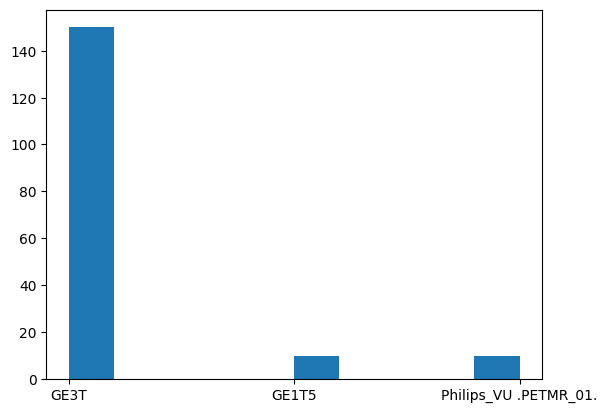

In [43]:
df["SCANNER"].hist(grid=False)

Let's compute some simple first order statistics on the available **T1w scans**

In [ ]:
def compute_brain_stats(x):
    return {
        "mean": np.mean(x),
        "std": np.std(x),
        "max": np.max(x),
        "min": np.min(x),
        "p01": np.percentile(x, 1),
        "p05": np.percentile(x, 5),
        "p95": np.percentile(x, 95),
        "p99": np.percentile(x, 99)
    }

def get_brain(t1w_filepath: str):
    with tempfile.TemporaryDirectory() as tmpdir:
        renamed_original_t1w_brain_filepath = f"{tmpdir}/T1w_brain.nii"
        shutil.copy2(t1w_filepath, renamed_original_t1w_brain_filepath)
        
        t1w_brain_filepath = f"{tmpdir}/T1w_brain.nii.gz"
        bet(
            renamed_original_t1w_brain_filepath,
            t1w_brain_filepath
        )
    
        return nib.load(t1w_brain_filepath).get_fdata()

stats_list = []
for _, row in tqdm(list(df.iterrows())):
    t1w_filepath = f"{WMH_DATASET_FOLDER}/" + row["T1W FILEPATH"]
    site = row["CENTER"]
    scanner = row["SCANNER"]
    t1w_array = nib.load(t1w_filepath).get_fdata()

    # removing background
    #t1w_array = t1w_array[t1w_array > 0]
    t1w_brain_array = get_brain(t1w_filepath)
    t1w_brain_array = t1w_brain_array[t1w_brain_array > 0]
    
    # robust scaling
    robust_scaled_t1w_array = RobustScaler().fit_transform(t1w_brain_array.reshape(-1, 1))
    
    stats = compute_brain_stats(robust_scaled_t1w_array)
    stats["site"] = site
    stats["scanner"] = scanner
    stats_list.append(stats)
    

stats_df = pd.DataFrame([ d.values() for d in stats_list], columns=stats_list[0].keys())

### Train an SVM classifier to predict site and scanner

#### Without COMBAT Harmonization

##### Site

In [ ]:
X = stats_df[["mean", "std", "max", "min", "p01", "p05", "p95", "p99"]].to_numpy()
y = stats_df["site"].to_numpy()

pipeline = Pipeline([
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="balanced_accuracy"
)

print("Accuracy:", scores.mean())
print("Std:", scores.std())

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Out-of-fold predictions
y_pred = cross_val_predict(
    pipeline,
    X,
    y,
    cv=cv
)

# Confusion matrix
cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=pipeline.classes_ if hasattr(pipeline, "classes_") else sorted(set(y))
)

disp.plot(cmap="Blues", values_format="d")
plt.title("SVM Site Classification — Confusion Matrix")
plt.xlabel("Predicted site")
plt.ylabel("True site")
plt.tight_layout()
plt.show()

##### Scanner

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline

X = stats_df[["mean", "std", "max", "min", "p01", "p05", "p95", "p99"]].to_numpy()
y = stats_df["scanner"].to_numpy()

pipeline = Pipeline([
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="balanced_accuracy"
)

print("Accuracy:", scores.mean())
print("Std:", scores.std())

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Out-of-fold predictions
y_pred = cross_val_predict(
    pipeline,
    X,
    y,
    cv=cv
)

# Confusion matrix
cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=pipeline.classes_ if hasattr(pipeline, "classes_") else sorted(set(y))
)

disp.plot(cmap="Blues", values_format="d")
plt.title("SVM Scanner Classification — Confusion Matrix")
plt.xlabel("Predicted scanner")
plt.ylabel("True scanner")
plt.tight_layout()
plt.show()

#### With COMBAT Harmonization

In [ ]:
features = stats_df[["mean", "std", "max", "min", "p01", "p05", "p95", "p99"]].T
covars = stats_df[["site", "scanner"]]

result = neuroCombat(
    dat=features,
    covars=covars,
    batch_col=["site", "scanner"]
)

X_harmonized = result["data"].T

##### Site

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline

X = X_harmonized
y = stats_df["site"].to_numpy()

pipeline = Pipeline([
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="balanced_accuracy"
)

print("Accuracy:", scores.mean())
print("Std:", scores.std())

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Out-of-fold predictions
y_pred = cross_val_predict(
    pipeline,
    X,
    y,
    cv=cv
)

# Confusion matrix
cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=pipeline.classes_ if hasattr(pipeline, "classes_") else sorted(set(y))
)

disp.plot(cmap="Blues", values_format="d")
plt.title("SVM Site Classification — Confusion Matrix")
plt.xlabel("Predicted site")
plt.ylabel("True site")
plt.tight_layout()
plt.show()

##### Scanner

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.pipeline import Pipeline

X = X_harmonized
y = stats_df["scanner"].to_numpy()

pipeline = Pipeline([
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="balanced_accuracy"
)

print("Accuracy:", scores.mean())
print("Std:", scores.std())

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Out-of-fold predictions
y_pred = cross_val_predict(
    pipeline,
    X,
    y,
    cv=cv
)

# Confusion matrix
cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=pipeline.classes_ if hasattr(pipeline, "classes_") else sorted(set(y))
)

disp.plot(cmap="Blues", values_format="d")
plt.title("SVM Scanner Classification — Confusion Matrix")
plt.xlabel("Predicted scanner")
plt.ylabel("True scanner")
plt.tight_layout()
plt.show()

### PCA Analysis

In [ ]:
stats_df.head()

In [ ]:
X = stats_df[["mean", "std", "max", "min", "p01", "p05", "p95", "p99"]].to_numpy()
y = stats_df["scanner"].to_numpy()

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

color_map = {
    'GE3T': '#ff7f0e',   # Orange
    'GE1T5': '#1f77b4',   # Blue
    'Philips_VU .PETMR_01.': '#2ca02c'   # Green
}
colors = [color_map[label] for label in y]

plt.scatter(X_pca[:,4], X_pca[:,1], c=colors)

In [ ]:
X = stats_df[["mean", "std", "max", "min", "p01", "p05", "p95", "p99"]].to_numpy()
y = stats_df["site"].to_numpy()

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

color_map = {
    'Amsterdam': '#ff7f0e',   # Orange
    'Utrecht': '#1f77b4',   # Blue
    'Singapore': '#2ca02c'   # Green
}
colors = [color_map[label] for label in y]

plt.scatter(X_pca[:,4], X_pca[:,0], c=colors)